In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mnno

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

plt.rcParams['figure.figsize'] = (9,5)
sns.set_style('whitegrid')
print('Libraries imported')

Libraries imported


In [2]:
df=pd.read_csv('C:/Users/GURPREET SINGH/Downloads/YourCabs.csv')
print('Shape:', df.shape)
df.head()

Shape: (43431, 18)


,id,user_id,vehicle_model_id,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation
0,132512,22177,28,2,NaN,83.0,448.0,NaN,NaN,01-01-2013 02:00,0,0,01-01-2013 01:39,12.924150,77.672290,12.927320,77.635750,0
1,132513,21413,12,2,NaN,1010.0,540.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 02:25,12.966910,77.749350,12.927680,77.626640,0
2,132514,22178,12,2,NaN,1301.0,1034.0,NaN,NaN,01-01-2013 03:30,0,0,01-01-2013 03:08,12.937222,77.626915,13.047926,77.597766,0
3,132515,13034,12,2,NaN,768.0,398.0,NaN,NaN,01-01-2013 05:45,0,0,01-01-2013 04:39,12.989990,77.553320,12.971430,77.639140,0
4,132517,22180,12,2,NaN,1365.0,849.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 07:53,12.845653,77.677925,12.954340,77.600720,0


In [3]:
df.describe

<bound method NDFrame.describe of            id  user_id  vehicle_model_id  travel_type_id  package_id  \
0      132512    22177                28               2         NaN   
1      132513    21413                12               2         NaN   
2      132514    22178                12               2         NaN   
3      132515    13034                12               2         NaN   
4      132517    22180                12               2         NaN   
...       ...      ...               ...             ...         ...   
43426  185937    14364                12               2         NaN   
43427  185938    48727                12               2         NaN   
43428  185939    48729                12               3         1.0   
43429  185940    30724                87               2         NaN   
43430  185941    48730                12               2         NaN   

       from_area_id  to_area_id  from_city_id  to_city_id         from_date  \
0              83.0   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43431 entries, 0 to 43430
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   43431 non-null  int64  
 1   user_id              43431 non-null  int64  
 2   vehicle_model_id     43431 non-null  int64  
 3   travel_type_id       43431 non-null  int64  
 4   package_id           7550 non-null   float64
 5   from_area_id         43343 non-null  float64
 6   to_area_id           34293 non-null  float64
 7   from_city_id         16345 non-null  float64
 8   to_city_id           1588 non-null   float64
 9   from_date            43431 non-null  object 
 10  online_booking       43431 non-null  int64  
 11  mobile_site_booking  43431 non-null  int64  
 12  booking_created      43431 non-null  object 
 13  from_lat             43338 non-null  float64
 14  from_long            43338 non-null  float64
 15  to_lat               34293 non-null 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,43431.0,NaN,NaN,NaN,159206.473556,15442.386279,132512.0,145778.0,159248.0,172578.5,185941.0
user_id,43431.0,NaN,NaN,NaN,30739.198153,10996.476709,16.0,24614.0,31627.0,39167.0,48730.0
vehicle_model_id,43431.0,NaN,NaN,NaN,25.71723,26.79825,1.0,12.0,12.0,24.0,91.0
travel_type_id,43431.0,NaN,NaN,NaN,2.137252,0.437712,1.0,2.0,2.0,2.0,3.0
package_id,7550.0,NaN,NaN,NaN,2.030066,1.461756,1.0,1.0,2.0,2.0,7.0
from_area_id,43343.0,NaN,NaN,NaN,714.544494,419.883553,2.0,393.0,590.0,1089.0,1403.0
to_area_id,34293.0,NaN,NaN,NaN,669.490917,400.638225,2.0,393.0,541.0,1054.0,1403.0
from_city_id,16345.0,NaN,NaN,NaN,14.915081,1.165306,1.0,15.0,15.0,15.0,31.0
to_city_id,1588.0,NaN,NaN,NaN,68.537783,49.880732,4.0,32.0,49.0,108.0,203.0
from_date,43431,20377,10-12-2013 06:00,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Columns with missing values:
 to_city_id      41843
package_id      35881
from_city_id    27086
to_long          9138
to_lat           9138
to_area_id       9138
from_long          93
from_lat           93
from_area_id       88
dtype: int64


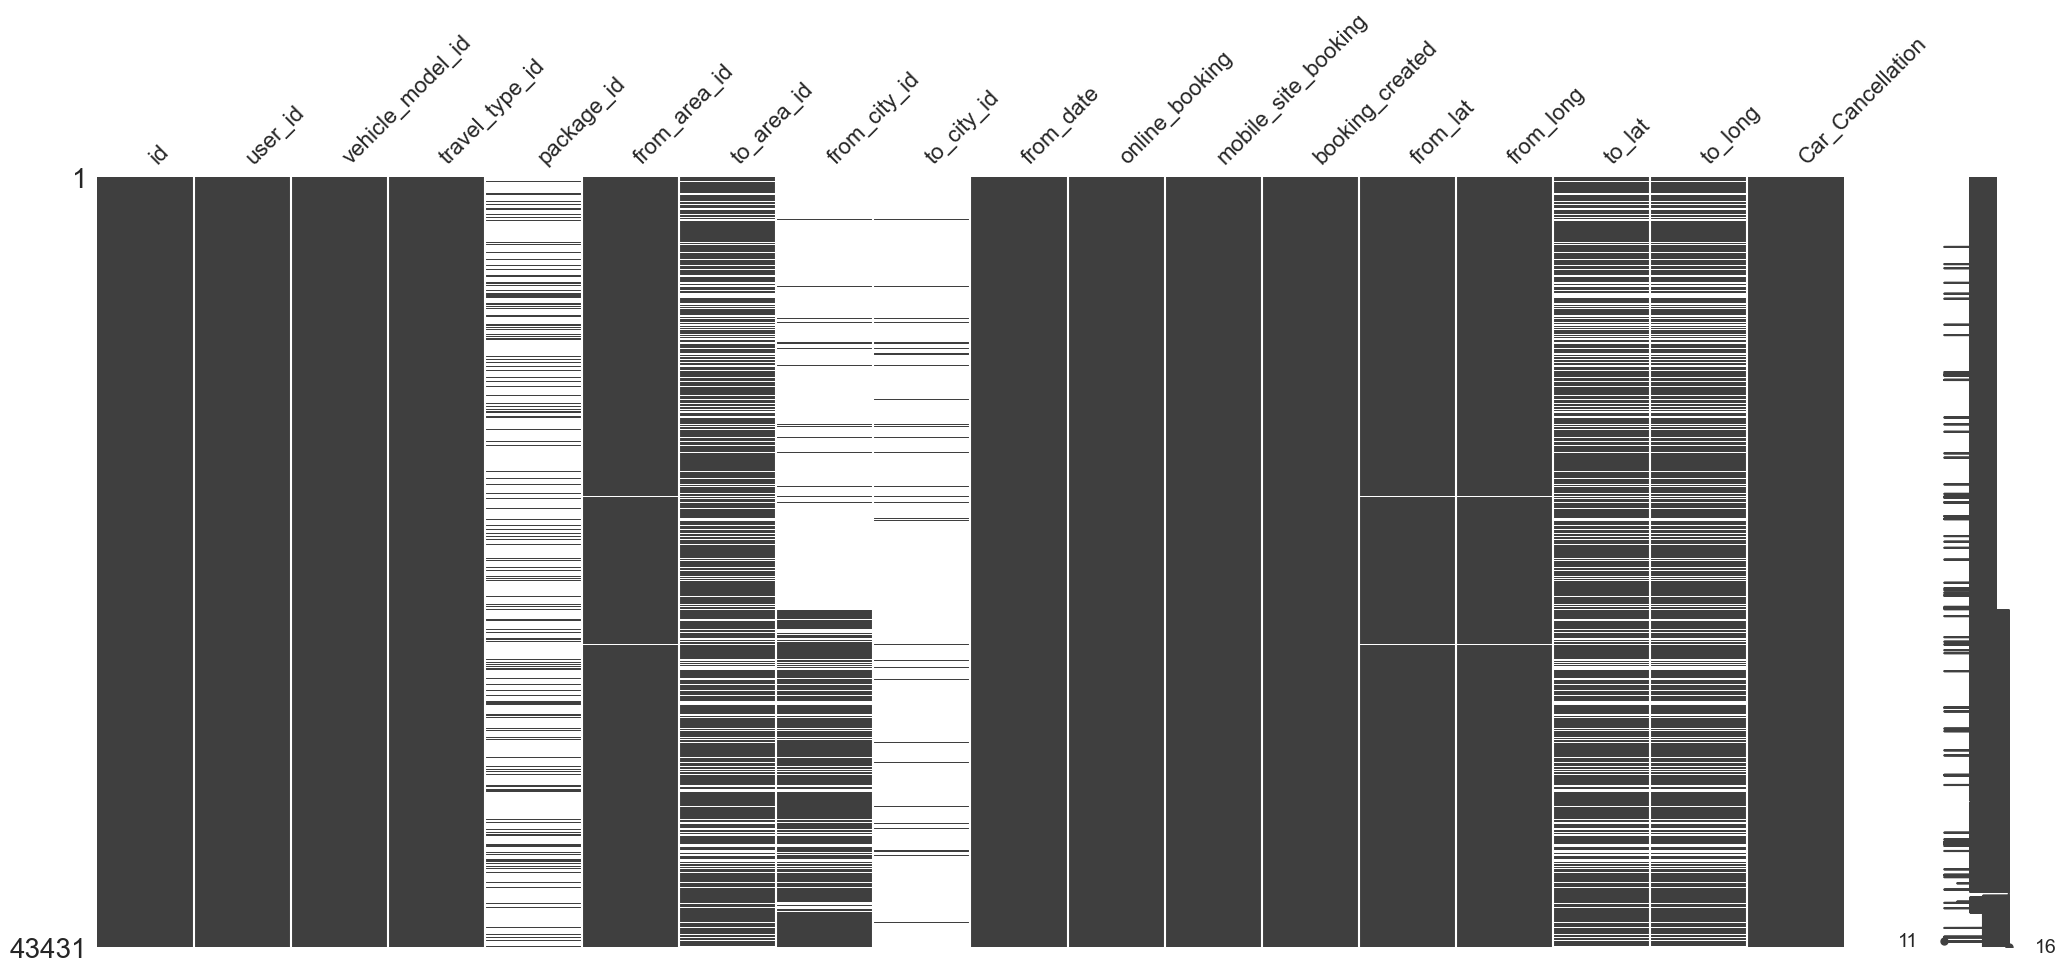

In [4]:
df.info()
print('\nNumeric summary:')
display(df.describe(include='all').T)

# Missing values per column
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing>0]
print('\nColumns with missing values:\n', missing)

# Visual missingness map (renders in notebook)
try:
    mnno.matrix(df)
    plt.show()
except Exception as e:
    print('missingno visual failed:', e)

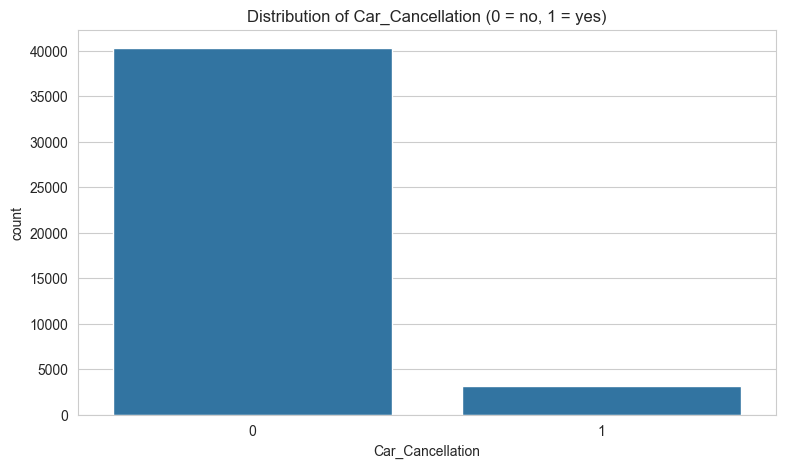

Car_Cancellation
0    0.927886
1    0.072114
Name: proportion, dtype: float64


In [5]:
if 'Car_Cancellation' in df.columns:
    sns.countplot(x='Car_Cancellation', data=df)
    plt.title('Distribution of Car_Cancellation (0 = no, 1 = yes)')
    plt.show()
    print(df['Car_Cancellation'].value_counts(normalize=True))
else:
    print('Car_Cancellation column not found')

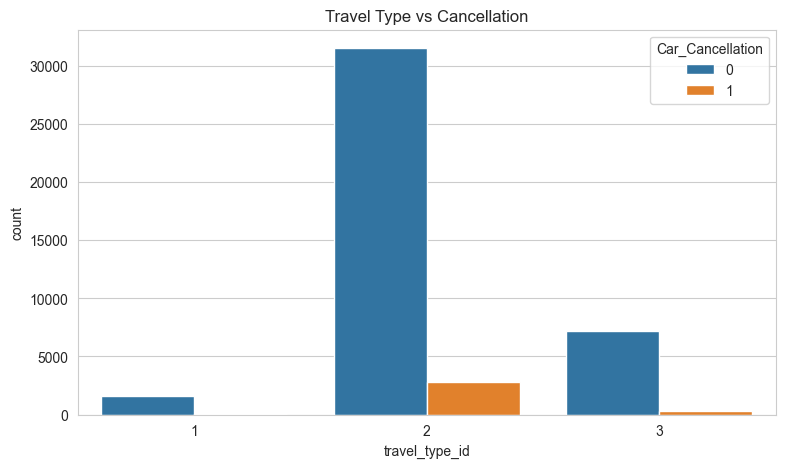

In [6]:
if 'travel_type_id' in df.columns and 'Car_Cancellation' in df.columns:
    sns.countplot(x='travel_type_id', hue='Car_Cancellation', data=df)
    plt.title('Travel Type vs Cancellation')
    plt.xlabel('travel_type_id')
    plt.show()

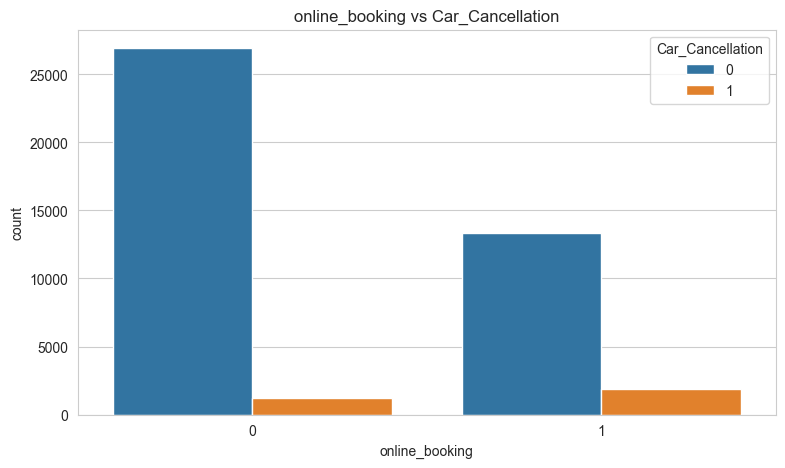

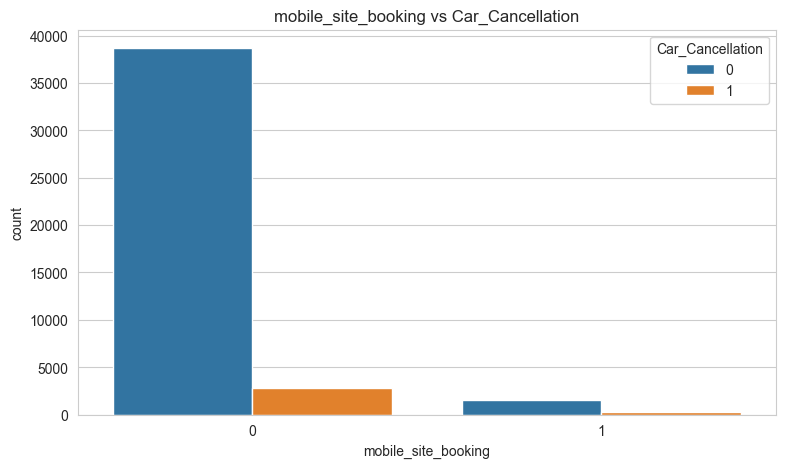

In [7]:
for col in ['online_booking', 'mobile_site_booking']:
    if col in df.columns and 'Car_Cancellation' in df.columns:
        sns.countplot(x=col, hue='Car_Cancellation', data=df)
        plt.title(f'{col} vs Car_Cancellation')
        plt.show()

In [8]:
# Make a copy to preprocess
df_proc = df.copy()

# Drop columns that are identifiers or mostly null
drop_cols = [c for c in ['id', 'user_id', 'package_id', 'to_area_id', 'to_city_id', 'to_lat', 'to_long'] if c in df_proc.columns]
df_proc.drop(columns=drop_cols, inplace=True)

# Convert datetime columns
if 'from_date' in df_proc.columns:
    df_proc['from_date'] = pd.to_datetime(df_proc['from_date'], errors='coerce')
if 'booking_created' in df_proc.columns:
    df_proc['booking_created'] = pd.to_datetime(df_proc['booking_created'], errors='coerce')

# Extract datetime features if from_date exists
if 'from_date' in df_proc.columns:
    df_proc['trip_hour'] = df_proc['from_date'].dt.hour
    df_proc['trip_weekday'] = df_proc['from_date'].dt.weekday
    df_proc['trip_month'] = df_proc['from_date'].dt.month

# time_diff in hours
if 'from_date' in df_proc.columns and 'booking_created' in df_proc.columns:
    df_proc['time_diff_hours'] = (df_proc['from_date'] - df_proc['booking_created']).dt.total_seconds() / 3600.0

# booking_nature based on time_diff_hours
def booking_nature(x):
    if pd.isna(x):
        return 'unknown'
    if x < 1:
        return 'urgent'
    if x <= 6:
        return 'same_day'
    if x <= 24:
        return 'regular'
    return 'advance'

if 'time_diff_hours' in df_proc.columns:
    df_proc['booking_nature'] = df_proc['time_diff_hours'].apply(booking_nature)

# Drop raw datetime columns (if still present)
for col in ['from_date', 'booking_created']:
    if col in df_proc.columns:
        df_proc.drop(columns=[col], inplace=True)

# Quick imputation for remaining missing values
impute_cols = df_proc.columns[df_proc.isnull().any()].tolist()

if impute_cols:
    imputer = SimpleImputer(strategy='most_frequent')
    df_proc[impute_cols] = pd.DataFrame(
        imputer.fit_transform(df_proc[impute_cols]),
        columns=impute_cols,
        index=df_proc.index
    )

print('After preprocessing shape:', df_proc.shape)
df_proc.head()



After preprocessing shape: (43431, 14)


,vehicle_model_id,travel_type_id,from_area_id,from_city_id,online_booking,mobile_site_booking,from_lat,from_long,Car_Cancellation,trip_hour,trip_weekday,trip_month,time_diff_hours,booking_nature
0,28,2,83.0,15.0,0,0,12.924150,77.672290,0,2.0,1.0,1.0,0.350000,urgent
1,12,2,1010.0,15.0,0,0,12.966910,77.749350,0,9.0,1.0,1.0,6.583333,regular
2,12,2,1301.0,15.0,0,0,12.937222,77.626915,0,3.0,1.0,1.0,0.366667,urgent
3,12,2,768.0,15.0,0,0,12.989990,77.553320,0,5.0,1.0,1.0,1.100000,same_day
4,12,2,1365.0,15.0,0,0,12.845653,77.677925,0,9.0,1.0,1.0,1.116667,same_day


In [9]:
# Ensure target exists
TARGET = 'Car_Cancellation'
if TARGET not in df_proc.columns:
    raise ValueError(f'Target column {TARGET} not found in dataset')

X = df_proc.drop(columns=[TARGET])
y = df_proc[TARGET].astype(int)  # ensure integer labels

# Select only reasonable columns (drop raw datetime objects if present)
X = X.drop(columns=[c for c in ['from_date','booking_created'] if c in X.columns])

# One-hot encode categorical columns
X_enc = pd.get_dummies(X, drop_first=True)

# Align train/test shape safety check
print('Feature matrix shape:', X_enc.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42, stratify=y)
print('Train/Test sizes:', X_train.shape, X_test.shape)

Feature matrix shape: (43431, 16)
Train/Test sizes: (34744, 16) (8687, 16)



Training Decision Tree
Accuracy: 0.9117 | Precision: 0.3110 | Recall: 0.1853 | F1: 0.2322

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      8061
           1       0.31      0.19      0.23       626

    accuracy                           0.91      8687
   macro avg       0.62      0.58      0.59      8687
weighted avg       0.89      0.91      0.90      8687



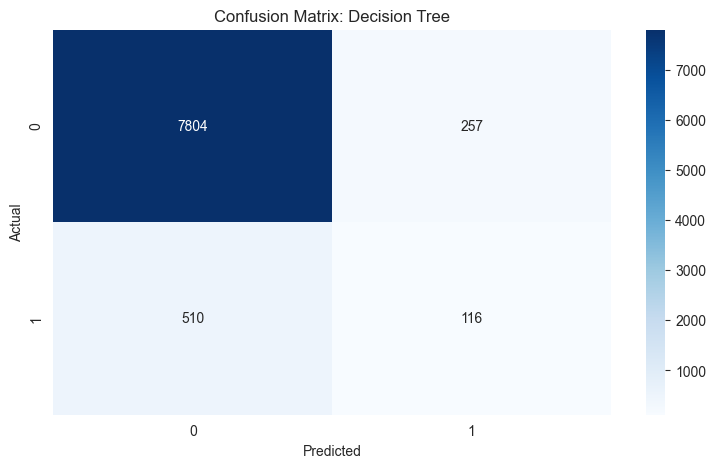


Training Random Forest
Accuracy: 0.9283 | Precision: 0.5106 | Recall: 0.1150 | F1: 0.1877

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96      8061
           1       0.51      0.12      0.19       626

    accuracy                           0.93      8687
   macro avg       0.72      0.55      0.58      8687
weighted avg       0.90      0.93      0.91      8687



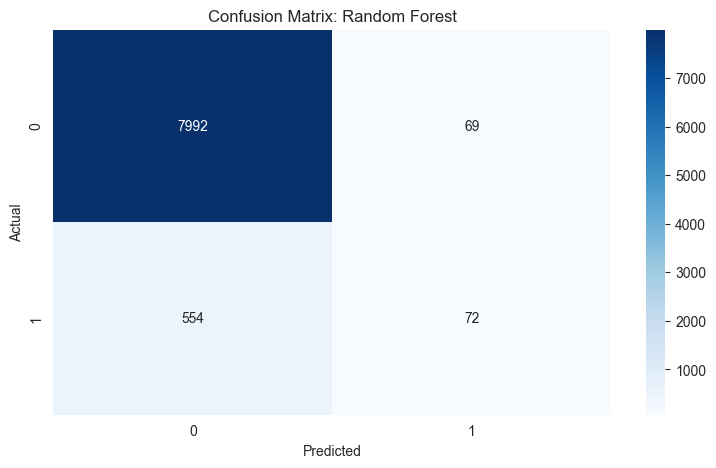


Training XGBoost
Accuracy: 0.9332 | Precision: 0.6643 | Recall: 0.1486 | F1: 0.2428

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.97      8061
           1       0.66      0.15      0.24       626

    accuracy                           0.93      8687
   macro avg       0.80      0.57      0.60      8687
weighted avg       0.92      0.93      0.91      8687



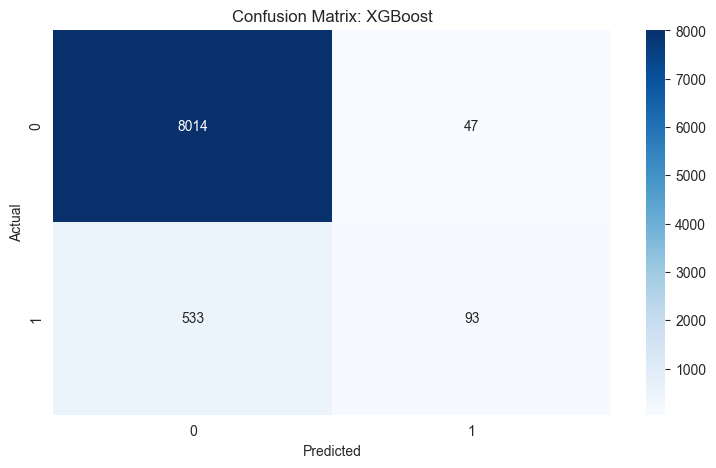

In [10]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    print('\nTraining', name)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    results[name] = {'model': model, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
    print(f'Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')
    print('\nClassification Report:\n', classification_report(y_test, preds, zero_division=0))
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

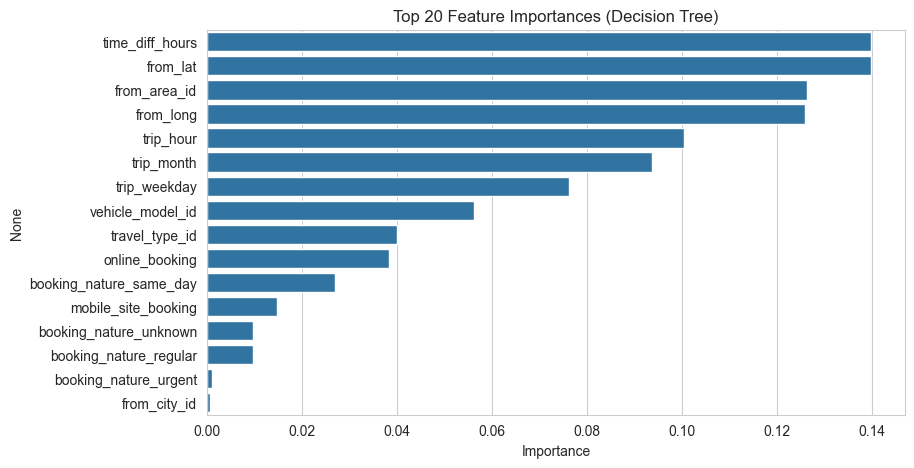

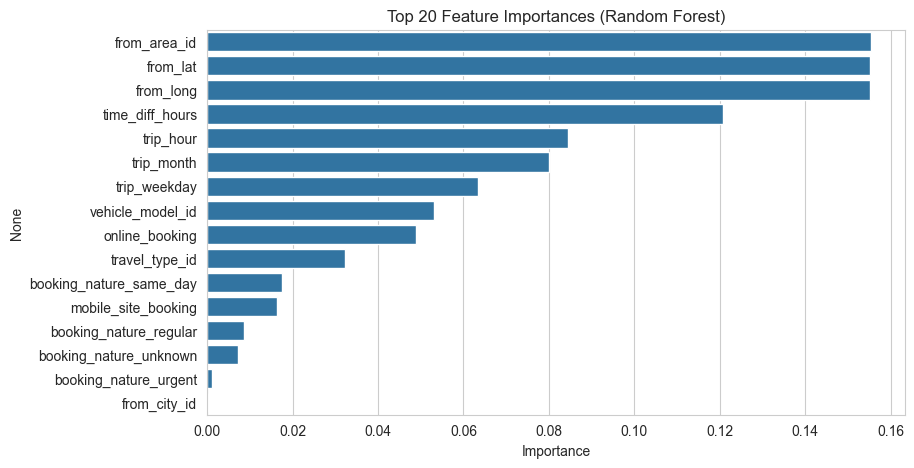

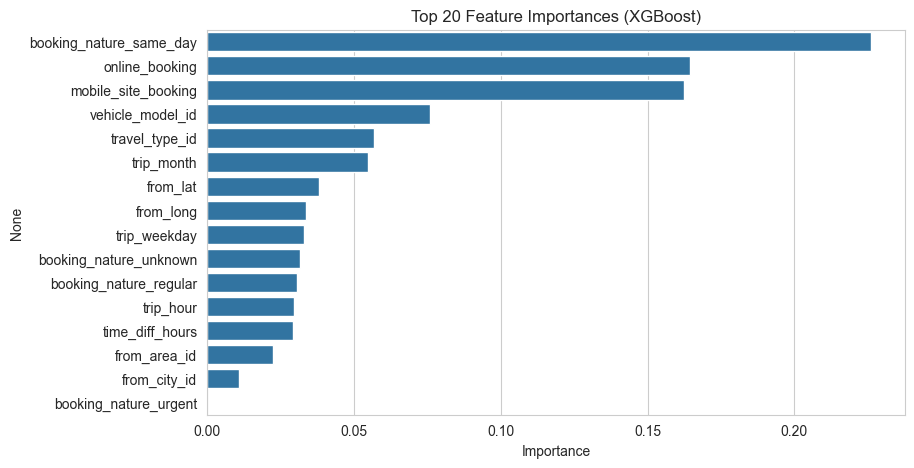

In [11]:
def plot_feature_importance(model, model_name, features, top_n=20):
    try:
        importances = model.feature_importances_
        fi = pd.Series(importances, index=features).sort_values(ascending=False).head(top_n)
        sns.barplot(x=fi.values, y=fi.index)
        plt.title(f'Top {top_n} Feature Importances ({model_name})')
        plt.xlabel('Importance')
        plt.show()
    except Exception as e:
        print(f"Feature importance not available for {model_name}: {e}")

# Plot for Decision Tree
dt_model = results.get('Decision Tree', {}).get('model', None)
if dt_model:
    plot_feature_importance(dt_model, "Decision Tree", X_enc.columns)

# Plot for Random Forest
rf_model = results.get('Random Forest', {}).get('model', None)
if rf_model:
    plot_feature_importance(rf_model, "Random Forest", X_enc.columns)

# Plot for XGBoost
xgb_model = results.get('XGBoost', {}).get('model', None)
if xgb_model:
    plot_feature_importance(xgb_model, "XGBoost", X_enc.columns)


In [12]:
# Drop IDs not useful for modeling
df_clean = df.drop(["id", "user_id"], axis=1)

# Fill missing values with -1 for safe handling
df_clean = df_clean.fillna(-1)


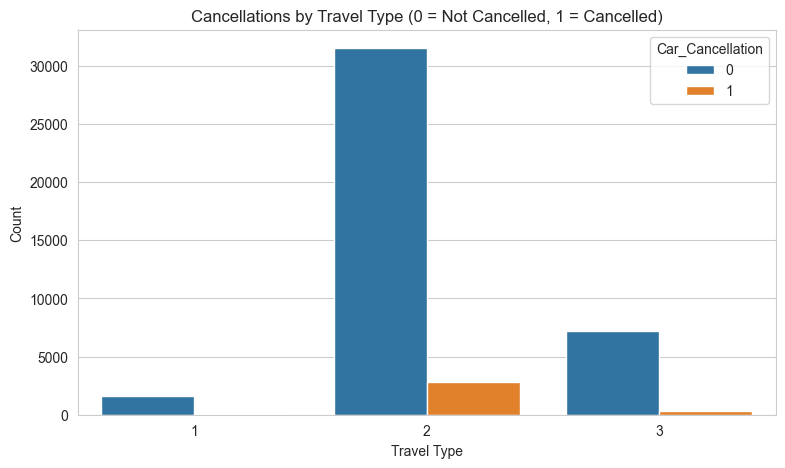

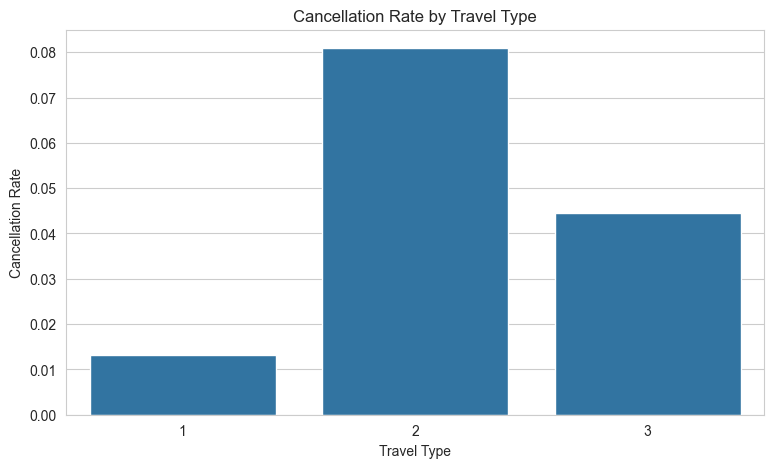

In [13]:
# Cancellation distribution by travel type
sns.countplot(x="travel_type_id", hue="Car_Cancellation", data=df)
plt.title("Cancellations by Travel Type (0 = Not Cancelled, 1 = Cancelled)")
plt.xlabel("Travel Type")
plt.ylabel("Count")
plt.show()

# Normalized cancellation rate
cxl_rate = df.groupby("travel_type_id")["Car_Cancellation"].mean()
sns.barplot(x=cxl_rate.index, y=cxl_rate.values)
plt.title("Cancellation Rate by Travel Type")
plt.xlabel("Travel Type")
plt.ylabel("Cancellation Rate")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

models = {}
reports = {}

for t in [1, 2, 3]:
    print(f"\n--- Travel Type {t} ---")
    
    # Filter dataset
    df_t = df_clean[df_clean["travel_type_id"] == t].copy()
    df_t = df_t.drop("travel_type_id", axis=1)
    
    # Split into features & target
    X = df_t.drop("Car_Cancellation", axis=1)
    y = df_t["Car_Cancellation"]
    
    # 🔹 One-hot encode categorical columns
    X = pd.get_dummies(X, drop_first=True)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    # 🔹 Faster Random Forest
    clf = RandomForestClassifier(
        n_estimators=50,   # fewer trees for speed
        max_depth=10,      # limit depth
        n_jobs=-1,         # use all CPU cores
        random_state=42
    )
    clf.fit(X_train, y_train)
    
    # Predictions
    y_pred = clf.predict(X_test)
    print(classification_report(y_test, y_pred))
    
    models[t] = clf
    reports[t] = classification_report(y_test, y_pred, output_dict=True)


--- Travel Type 1 ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       314
           1       0.00      0.00      0.00         4

    accuracy                           0.99       318
   macro avg       0.49      0.50      0.50       318
weighted avg       0.98      0.99      0.98       318


--- Travel Type 2 ---


In [ ]:
# Booking nature categorization
def booking_nature(x):
    if pd.isna(x): return "Unknown"
    if x < 1: return "Urgent"
    elif x < 24: return "SameDay"
    elif x < 168: return "Regular"
    else: return "Advance"

# Preprocessing per travel type
def preprocess_travel_type(df_t, travel_type):
    df_t = df_t.copy()
    
    # Convert datetime
    df_t["from_date"] = pd.to_datetime(df_t["from_date"], errors="coerce")
    df_t["booking_created"] = pd.to_datetime(df_t["booking_created"], errors="coerce")
    
    # Time difference & booking nature
    df_t["time_diff_hours"] = (df_t["from_date"] - df_t["booking_created"]).dt.total_seconds() / 3600
    df_t["booking_nature"] = df_t["time_diff_hours"].apply(booking_nature)
    
    # Extract datetime parts
    df_t["day_of_week"] = df_t["from_date"].dt.dayofweek
    df_t["month"] = df_t["from_date"].dt.month
    df_t["hour"] = df_t["from_date"].dt.hour
    
    # Drop raw datetime
    df_t = df_t.drop(["from_date","booking_created"], axis=1)
    
    # Travel type specific handling
    if travel_type == 1:
        df_t = df_t.drop(["package_id","from_lat","from_long","to_lat","to_long"], axis=1, errors="ignore")
        
        # Area cancellation volume
        area_rate = df_t.groupby("from_area_id")["Car_Cancellation"].mean()
        bins = [-1, 0.05, 0.15, 0.30, 1.0]
        labels = ["Zero", "Low", "Medium", "High"]
        df_t["from_area_cxl_vol"] = pd.cut(df_t["from_area_id"].map(area_rate), bins=bins, labels=labels)
        
        # City routes cancellation volume
        df_t["city_route"] = df_t["from_city_id"].astype(str)+"_"+df_t["to_city_id"].astype(str)
        route_rate = df_t.groupby("city_route")["Car_Cancellation"].mean()
        df_t["city_route_cxl_vol"] = pd.cut(df_t["city_route"].map(route_rate), bins=bins, labels=labels)
        
        df_t = df_t.drop(["from_area_id","to_area_id","from_city_id","to_city_id","city_route"], axis=1, errors="ignore")
    
    elif travel_type == 2:
        df_t = df_t.drop(["from_city_id","to_city_id","from_lat","from_long","to_lat","to_long"], axis=1, errors="ignore")
    
    elif travel_type == 3:
        df_t = df_t.drop(["from_city_id","to_city_id","from_lat","from_long","to_lat","to_long"], axis=1, errors="ignore")
    
    return df_t.fillna(-1)


In [ ]:
# ==========================================================
# AIM 3: Feature Engineering for Each Travel Type
# ==========================================================

## 1. Feature Engineering

df_type = df.copy()

# Convert datetime columns safely
df_type["from_date"] = pd.to_datetime(df_type["from_date"], errors="coerce")
df_type["booking_created"] = pd.to_datetime(df_type["booking_created"], errors="coerce")

# Calculate booking window (hours between booking and trip)
df_type["booking_window"] = (
    (df_type["from_date"] - df_type["booking_created"]).dt.total_seconds() / 3600.0
)

# Extract datetime components
df_type["trip_hour"] = df_type["from_date"].dt.hour
df_type["trip_weekday"] = df_type["from_date"].dt.weekday
df_type["trip_month"] = df_type["from_date"].dt.month

# Drop raw datetime columns
df_type = df_type.drop(columns=["from_date", "booking_created"], errors="ignore")

print("Feature engineering completed. Shape:", df_type.shape)
df_type.head()


In [ ]:
## 2. Data Visualization: Travel Type & Cancellation

import matplotlib.pyplot as plt
import seaborn as sns

# Travel Type vs Cancellation
plt.figure(figsize=(7,4))
sns.countplot(x="travel_type_id", hue="Car_Cancellation", data=df_type)
plt.title("Travel Type vs Cancellation")
plt.xlabel("Travel Type")
plt.ylabel("Count")
plt.show()

# Booking Window distribution by Travel Type
plt.figure(figsize=(8,4))
sns.boxplot(x="travel_type_id", y="booking_window", data=df_type)
plt.title("Booking Window Distribution by Travel Type")
plt.xlabel("Travel Type")
plt.ylabel("Booking Window (hours)")
plt.show()


In [ ]:
## 3. Prepare Data for Modeling

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

TARGET = "Car_Cancellation"
X = df_type.drop(columns=[TARGET])
y = df_type[TARGET]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train/Test shapes:", X_train.shape, X_test.shape)


In [ ]:
## 4. Train & Evaluate Model

clf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:
## 5. Feature Importance

feat_imp = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()
